이 코드는 크게 4단계로 구성됩니다.

[설정] 경로 및 클래스 정의

[전처리] 데이터셋 구축 (Stage 1 Crop + 좌표 변환 + 멀티 클래스)

[학습] Stage 2 모델 학습 (속도 최적화 적용)

[평가] 계층적(Major vs Minor) 성능 평가

In [ ]:
### train시 1시간 정도 소모 됩니다. colab환경에서 아래를 browser의 console 에서 붙여 넣기가 필요할 수 있습니다.
### shift+cntr+i 로 browser console 열기
# https://github.com/chulminkw/DLCV/blob/master/data/util/colab_autoclick.js
'''
function ClickConnect(){
console.log("Working");
document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect,60000)
'''

# Step 1. 라이브러리 임포트 및 환경 설정

In [1]:
# YOLOv8 및 데이터 처리에 필요한 라이브러리 설치
!pip install ultralytics tqdm

import os
import glob
import shutil
import random
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from google.colab import drive

# 1. 구글 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("✅ 환경 설정 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
✅ 환경 설정 완료


In [ ]:
import os

# 1. 압축을 풀 폴더 생성 (파일이 섞이지 않게 폴더를 따로 만드는 것이 좋습니다)
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

# 2. 압축 해제 실행
# -q: Quiet 모드 (로그 숨김 -> 속도 향상)
# -d: Destination (저장할 경로 지정)
!unzip -q /content/AI_HUB_DAMAGE_DATASET.zip -d {extract_path}
!unzip -q /content/RAW.zip -d {extract_path}

print(f"✅ 압축 해제 완료! 경로: {extract_path}")

✅ 압축 해제 완료! 경로: /content/dataset


In [ ]:
# =========================================================
# ⚙️ [설정] 경로 및 파라미터
# =========================================================

# [입력 데이터 경로 (Colab Local)]
AI_HUB_IMG_ROOT = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/AI_HUB_DAMAGE_DATASET/images" # 속도 개선을 위해 content에 직접 업로드
AI_HUB_LBL_ROOT = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/AI_HUB_DAMAGE_DATASET/labels"

#AI_HUB_IMG_ROOT = "/content/dataset/AI_HUB_DAMAGE_DATASET/images"
#AI_HUB_LBL_ROOT = "/content/dataset/AI_HUB_DAMAGE_DATASET/labels"
NORMAL_ROOT_BASE = "/content/dataset/RAW"

# [출력 데이터셋 경로 (Google Drive)]
DATASET_ROOT = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI"

# [Stage 1 모델 경로]
STAGE1_MODEL_PATH = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK1_CAR_DETECTION/FINE_TUNING_MODEL/yolov8x_fine_tuning_5th/weights/best.pt"

# [파라미터]
IMG_SIZE = 640
MARGIN_RATIO = 0.15
CONF_THRES = 0.1  # 차량 탐지 민감도
SEED = 42

# [타겟 클래스 정의]
# Dent 제외, 중요도 순서
TARGET_CLASS_NAMES = [
    'Scratched',   # 0
    'Separated',   # 1
    'Breakage',    # 2
    'Crushed'      # 3
]

random.seed(SEED)
np.random.seed(SEED)

print(f"📂 데이터셋 생성 위치: {DATASET_ROOT}")
print(f"🎯 타겟 클래스: {TARGET_CLASS_NAMES}")

📂 데이터셋 생성 위치: /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI
🎯 타겟 클래스: ['Scratched', 'Separated', 'Breakage', 'Crushed']


# Step 2. 데이터셋 구축 (전처리 & Crop)

In [ ]:
# ---------------------------------------------------------------------
# 🛠️ 유틸리티 함수 정의
# ---------------------------------------------------------------------

def clamp(value, min_val, max_val):
    return max(min_val, min(value, max_val))

def get_vehicle_crop_box(image, model, margin=0.15):
    """Stage 1: 차량 탐지 및 Crop 좌표 계산 (Recall 확보)"""
    h_img, w_img = image.shape[:2]

    # 1. 추론
    results = model(image, verbose=False, conf=0.1)

    best_box = None
    max_area = 0

    # 가장 큰 박스(차량) 선택
    for r in results:
        for box in r.boxes:
            coords = box.xyxy[0].cpu().numpy()
            area = (coords[2] - coords[0]) * (coords[3] - coords[1])
            if area > max_area:
                max_area = area
                best_box = coords

    # 2. Fallback
    if best_box is None:
        return 0, 0, w_img, h_img, False

    # 3. Margin 적용 & Clamp
    x1, y1, x2, y2 = best_box
    w_box = x2 - x1; h_box = y2 - y1

    nx1 = int(clamp(x1 - w_box * margin, 0, w_img))
    ny1 = int(clamp(y1 - h_box * margin, 0, h_img))
    nx2 = int(clamp(x2 + w_box * margin, 0, w_img))
    ny2 = int(clamp(y2 + h_box * margin, 0, h_img))

    return nx1, ny1, nx2, ny2, True

def convert_label_global_to_local(src_txt_path, crop_coords, src_size):
    """원본 라벨(Global) -> Crop 라벨(Local) 변환 (클래스 ID 유지)"""
    if not os.path.exists(src_txt_path):
        return []

    cx1, cy1, cx2, cy2 = crop_coords
    w_org, h_org = src_size
    crop_w = cx2 - cx1; crop_h = cy2 - cy1

    new_labels = []

    with open(src_txt_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5: continue

        cls = int(parts[0])

        # 정의된 클래스(0~3) 외(예: Dent=4)는 제외됨
        if cls >= len(TARGET_CLASS_NAMES):
            continue

        n_cx, n_cy, n_w, n_h = map(float, parts[1:5])

        # 좌표 변환 로직
        gx_center = n_cx * w_org; gy_center = n_cy * h_org
        gw = n_w * w_org; gh = n_h * h_org

        gx1 = gx_center - gw/2; gy1 = gy_center - gh/2
        gx2 = gx_center + gw/2; gy2 = gy_center + gh/2

        ix1 = max(gx1, cx1); iy1 = max(gy1, cy1)
        ix2 = min(gx2, cx2); iy2 = min(gy2, cy2)

        if ix2 <= ix1 or iy2 <= iy1: continue

        lx1 = ix1 - cx1; ly1 = iy1 - cy1
        lx2 = ix2 - cx1; ly2 = iy2 - cy1
        lw = lx2 - lx1; lh = ly2 - ly1

        if lw < 2 or lh < 2: continue

        final_cx = (lx1 + lw/2) / crop_w
        final_cy = (ly1 + lh/2) / crop_h
        final_w = lw / crop_w
        final_h = lh / crop_h

        final_cx = clamp(final_cx, 0, 1); final_cy = clamp(final_cy, 0, 1)
        final_w = clamp(final_w, 0, 1); final_h = clamp(final_h, 0, 1)

        new_labels.append(f"{cls} {final_cx:.6f} {final_cy:.6f} {final_w:.6f} {final_h:.6f}")

    return new_labels

def process_and_save(src_img_path, src_lbl_path, dst_img_path, dst_txt_path, model):
    img = cv2.imread(src_img_path)
    if img is None: return False

    h_org, w_org = img.shape[:2]

    # Crop
    cx1, cy1, cx2, cy2, detected = get_vehicle_crop_box(img, model, MARGIN_RATIO)
    crop_w = cx2 - cx1; crop_h = cy2 - cy1
    if crop_w <= 0 or crop_h <= 0: return False

    # Resize
    crop_img = img[cy1:cy2, cx1:cx2]
    resized_img = cv2.resize(crop_img, (IMG_SIZE, IMG_SIZE))

    # Label Conversion
    final_labels = []
    if src_lbl_path:
        final_labels = convert_label_global_to_local(
            src_lbl_path, (cx1, cy1, cx2, cy2), (w_org, h_org)
        )

    # Save
    cv2.imwrite(dst_img_path, resized_img)
    with open(dst_txt_path, 'w') as f:
        if final_labels:
            f.write("\n".join(final_labels))

    return True

# ---------------------------------------------------------------------
# 🚀 메인 실행 로직
# ---------------------------------------------------------------------
def build_dataset_drive_multi():
    if os.path.exists(DATASET_ROOT):
        print(f"⚠️ 기존 폴더 삭제 후 재생성: {DATASET_ROOT}")
        shutil.rmtree(DATASET_ROOT)

    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(DATASET_ROOT, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(DATASET_ROOT, 'labels', split), exist_ok=True)

    print(f"🚀 Stage 1 모델 로드 중... ({os.path.basename(STAGE1_MODEL_PATH)})")
    if not os.path.exists(STAGE1_MODEL_PATH):
        print(f"❌ 오류: 모델 파일이 없습니다: {STAGE1_MODEL_PATH}")
        return
    model = YOLO(STAGE1_MODEL_PATH)

    print("📂 파일 리스트 수집 중...")
    exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']

    # Damaged
    d_files = []
    for ext in exts:
        d_files.extend(glob.glob(os.path.join(AI_HUB_IMG_ROOT, "**", ext), recursive=True))
    d_files = list(set(d_files))

    # Normal
    n_files = []
    for folder in ['normal', 'normal(kaggle_dataset)']:
        path = os.path.join(NORMAL_ROOT_BASE, folder)
        if os.path.exists(path):
            for ext in exts:
                n_files.extend(glob.glob(os.path.join(path, "**", ext), recursive=True))
    n_files = list(set(n_files))

    print(f"   - Damaged: {len(d_files)}")
    print(f"   - Normal : {len(n_files)}")

    # Split
    def split_data(files):
        if not files: return [], [], []
        t, test = train_test_split(files, test_size=0.1, random_state=SEED)
        t, val = train_test_split(t, test_size=0.2222, random_state=SEED)
        return t, val, test

    dt, dv, dts = split_data(d_files)
    nt, nv, nts = split_data(n_files)

    tasks = [
        ('train', dt, 'damaged'), ('val', dv, 'damaged'), ('test', dts, 'damaged'),
        ('train', nt, 'normal'),  ('val', nv, 'normal'),  ('test', nts, 'normal')
    ]

    print("⚡ 데이터셋 생성 시작 (구글 드라이브에 저장)...")
    total_count = 0
    for split, files, kind in tasks:
        for file_path in tqdm(files, desc=f"[{split}] {kind}"):
            fname = os.path.basename(file_path)
            basename = os.path.splitext(fname)[0]

            dst_img = os.path.join(DATASET_ROOT, 'images', split, fname)
            dst_txt = os.path.join(DATASET_ROOT, 'labels', split, basename + ".txt")

            src_lbl = None
            if kind == 'damaged':
                try:
                    rel = os.path.relpath(os.path.dirname(file_path), AI_HUB_IMG_ROOT)
                    cand = os.path.join(AI_HUB_LBL_ROOT, rel, basename + ".txt")
                    if os.path.exists(cand): src_lbl = cand
                except: pass
                if not src_lbl:
                    cand = os.path.join(AI_HUB_LBL_ROOT, basename + ".txt")
                    if os.path.exists(cand): src_lbl = cand
                if not src_lbl: continue

            if process_and_save(file_path, src_lbl, dst_img, dst_txt, model):
                total_count += 1

    # YAML 생성
    yaml_content = f"""
path: {DATASET_ROOT}
train: images/train
val: images/val
test: images/test

nc: {len(TARGET_CLASS_NAMES)}
names: {TARGET_CLASS_NAMES}
"""
    # [수정됨] 파일명을 data_multi_drive.yaml로 통일
    yaml_path = os.path.join(DATASET_ROOT, "data_multi_drive.yaml")
    with open(yaml_path, "w") as f:
        f.write(yaml_content)

    print(f"\n✅ 완료! 총 {total_count}장")
    print(f"   YAML 경로: {yaml_path}")

build_dataset_drive_multi()

🚀 Stage 1 모델 로드 중... (best.pt)
📂 파일 리스트 수집 중...
   - Damaged: 12000
   - Normal : 1077
⚡ 데이터셋 생성 시작 (구글 드라이브에 저장)...


[train] damaged:   0%|          | 0/8400 [00:00<?, ?it/s]

[val] damaged:   0%|          | 0/2400 [00:00<?, ?it/s]

[test] damaged:   0%|          | 0/1200 [00:00<?, ?it/s]

[train] normal:   0%|          | 0/753 [00:00<?, ?it/s]

[val] normal:   0%|          | 0/216 [00:00<?, ?it/s]

[test] normal:   0%|          | 0/108 [00:00<?, ?it/s]


✅ 완료! 총 13077장
   YAML 경로: /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI/data_multi_drive.yaml


## 시각화 (검증)

In [ ]:
def visualize_random_samples(num_samples=3):
    test_img_dir = os.path.join(DATASET_ROOT, 'images', 'test')
    test_lbl_dir = os.path.join(DATASET_ROOT, 'labels', 'test')

    candidates = []
    if not os.path.exists(test_lbl_dir):
        print("❌ 라벨 폴더가 없습니다.")
        return

    for txt_file in os.listdir(test_lbl_dir):
        if os.path.getsize(os.path.join(test_lbl_dir, txt_file)) > 0:
            candidates.append(txt_file)

    if not candidates:
        print("❌ 시각화할 파손 데이터가 없습니다.")
        return

    samples = random.sample(candidates, min(len(candidates), num_samples))
    plt.figure(figsize=(15, 5))

    for i, txt_name in enumerate(samples):
        basename = os.path.splitext(txt_name)[0]
        img_name = basename + ".jpg"
        if not os.path.exists(os.path.join(test_img_dir, img_name)):
            img_name = basename + ".png"

        img_path = os.path.join(test_img_dir, img_name)
        txt_path = os.path.join(test_lbl_dir, txt_name)

        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        with open(txt_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls, cx, cy, bw, bh = map(float, parts[:5])
                    x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)

                    # [수정됨] 실제 클래스 이름 표시
                    cls_name = TARGET_CLASS_NAMES[int(cls)]
                    color = (255, 0, 0)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(img, cls_name, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"Sample {i+1}\n{basename}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("🔍 생성된 데이터셋 검증")

🔍 생성된 데이터셋 검증


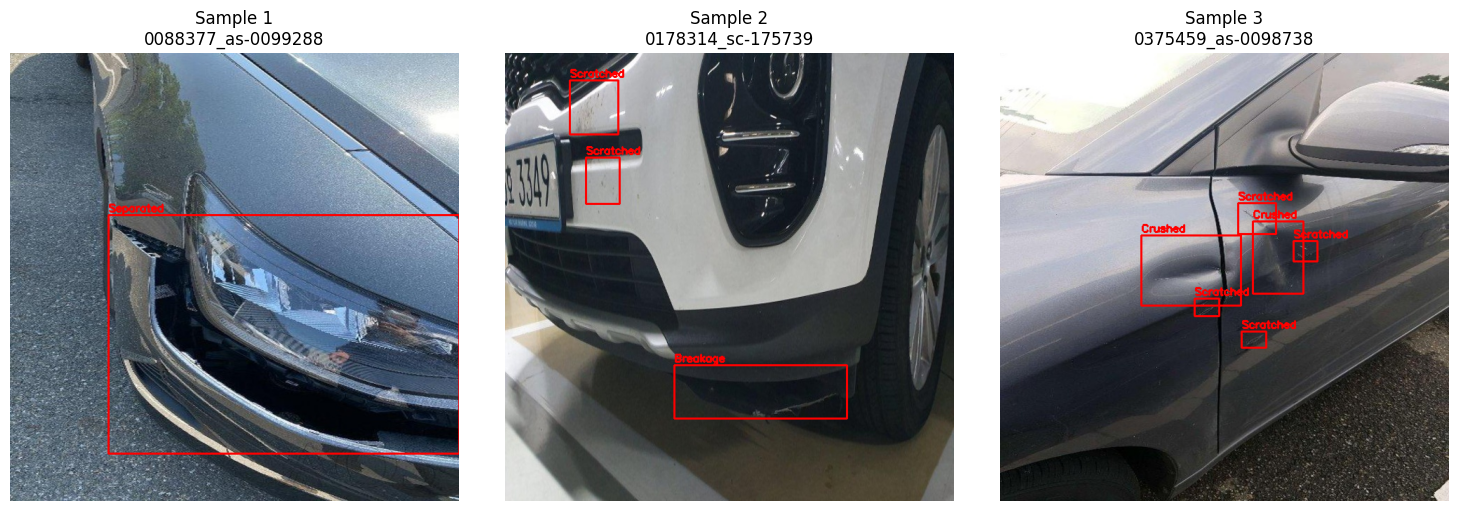

In [ ]:
visualize_random_samples()

In [ ]:
import matplotlib.patches as patches

def visualize_crop_comparison(model_path, num_samples=3):
    """
    Stage 1 전처리 검증 시각화
    - 좌측: 원본 이미지 + 원본 라벨 (Global)
    - 우측: Crop 이미지 + 변환 라벨 (Local)
    """
    print(f"🔍 전처리 로직 검증 (원본 vs Crop 비교) - {num_samples}장 샘플링")

    # 1. 모델 로드
    if not os.path.exists(model_path):
        print("❌ 모델 파일이 없습니다.")
        return
    model = YOLO(model_path)

    # 2. 원본 데이터 파일 리스트업 (Damaged 데이터만)
    all_img_files = glob.glob(os.path.join(AI_HUB_IMG_ROOT, "**", "*.jpg"), recursive=True) + \
                    glob.glob(os.path.join(AI_HUB_IMG_ROOT, "**", "*.png"), recursive=True)

    if not all_img_files:
        print("❌ 원본 데이터가 없습니다.")
        return

    # 3. 랜덤 샘플링 (라벨이 있는 파일만 찾을 때까지 반복)
    samples_found = 0
    sampled_pairs = [] # (img_path, lbl_path)

    random.shuffle(all_img_files)

    for img_path in all_img_files:
        if samples_found >= num_samples: break

        basename = os.path.splitext(os.path.basename(img_path))[0]
        # 라벨 찾기 (상대 경로 or 직접 경로)
        lbl_path = None
        try:
            rel = os.path.relpath(os.path.dirname(img_path), AI_HUB_IMG_ROOT)
            cand = os.path.join(AI_HUB_LBL_ROOT, rel, basename + ".txt")
            if os.path.exists(cand): lbl_path = cand
        except: pass

        if not lbl_path:
            cand = os.path.join(AI_HUB_LBL_ROOT, basename + ".txt")
            if os.path.exists(cand): lbl_path = cand

        if lbl_path and os.path.getsize(lbl_path) > 0:
            sampled_pairs.append((img_path, lbl_path))
            samples_found += 1

    # 4. 시각화 실행
    for idx, (src_img_path, src_lbl_path) in enumerate(sampled_pairs):
        # 이미지 로드
        img = cv2.imread(src_img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_org, w_org = img.shape[:2]

        # --- [Step 1] 원본 라벨 파싱 ---
        org_boxes = [] # (cls, x1, y1, x2, y2)
        with open(src_lbl_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    c, cx, cy, w, h = map(float, parts[:5])
                    # Denormalize
                    x1 = int((cx - w/2) * w_org)
                    y1 = int((cy - h/2) * h_org)
                    x2 = int((cx + w/2) * w_org)
                    y2 = int((cy + h/2) * h_org)
                    if int(c) < len(TARGET_CLASS_NAMES):
                        org_boxes.append((int(c), x1, y1, x2, y2))

        # --- [Step 2] Crop & Transform 실행 ---
        cx1, cy1, cx2, cy2, detected = get_vehicle_crop_box(img, model, MARGIN_RATIO)

        # Crop 이미지 생성
        crop_img = img_rgb[cy1:cy2, cx1:cx2].copy()
        crop_h, crop_w = crop_img.shape[:2]

        # 라벨 변환 (함수 재사용)
        local_labels = convert_label_global_to_local(src_lbl_path, (cx1, cy1, cx2, cy2), (w_org, h_org))

        # --- [Step 3] Plotting ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # (좌측) 원본 이미지
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"[Original] {os.path.basename(src_img_path)}\nSize: {w_org}x{h_org}")

        # 원본 박스 그리기
        for (cls, x1, y1, x2, y2) in org_boxes:
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
            axes[0].add_patch(rect)
            axes[0].text(x1, y1-5, TARGET_CLASS_NAMES[cls], color='red', fontsize=10, weight='bold', backgroundcolor='white')

        # Crop 영역 표시 (초록색 점선)
        crop_rect = patches.Rectangle((cx1, cy1), cx2-cx1, cy2-cy1, linewidth=2, edgecolor='green', linestyle='--', facecolor='none')
        axes[0].add_patch(crop_rect)
        axes[0].text(cx1, cy1-5, "Crop Area", color='green', fontsize=10, weight='bold')

        # (우측) Crop 이미지
        axes[1].imshow(crop_img)
        axes[1].set_title(f"[Cropped] {detected and 'Vehicle Detected' or 'Fallback'}\nSize: {crop_w}x{crop_h}")

        # 변환된 박스 그리기
        for line in local_labels:
            parts = line.split()
            cls, cx, cy, w, h = map(float, parts)
            # Denormalize (Crop 기준)
            lx1 = int((cx - w/2) * crop_w)
            ly1 = int((cy - h/2) * crop_h)
            lx2 = int((cx + w/2) * crop_w)
            ly2 = int((cy + h/2) * crop_h)

            rect = patches.Rectangle((lx1, ly1), lx2-lx1, ly2-ly1, linewidth=2, edgecolor='blue', facecolor='none')
            axes[1].add_patch(rect)
            axes[1].text(lx1, ly1-5, TARGET_CLASS_NAMES[int(cls)], color='blue', fontsize=10, weight='bold', backgroundcolor='white')

        plt.tight_layout()
        plt.show()


In [ ]:

def clamp(value, min_val, max_val):
    return max(min_val, min(value, max_val))

def get_vehicle_crop_box(image, model, margin=0.15):
    """Stage 1: 차량 탐지 및 Crop 좌표 계산 (Recall 확보)"""
    h_img, w_img = image.shape[:2]

    # 1. 추론
    results = model(image, verbose=False, conf=0.1)

    best_box = None
    max_area = 0

    # 가장 큰 박스(차량) 선택
    for r in results:
        for box in r.boxes:
            coords = box.xyxy[0].cpu().numpy()
            area = (coords[2] - coords[0]) * (coords[3] - coords[1])
            if area > max_area:
                max_area = area
                best_box = coords

    # 2. Fallback
    if best_box is None:
        return 0, 0, w_img, h_img, False

    # 3. Margin 적용 & Clamp
    x1, y1, x2, y2 = best_box
    w_box = x2 - x1; h_box = y2 - y1

    nx1 = int(clamp(x1 - w_box * margin, 0, w_img))
    ny1 = int(clamp(y1 - h_box * margin, 0, h_img))
    nx2 = int(clamp(x2 + w_box * margin, 0, w_img))
    ny2 = int(clamp(y2 + h_box * margin, 0, h_img))

    return nx1, ny1, nx2, ny2, True

def convert_label_global_to_local(src_txt_path, crop_coords, src_size):
    """원본 라벨(Global) -> Crop 라벨(Local) 변환 (클래스 ID 유지)"""
    if not os.path.exists(src_txt_path):
        return []

    cx1, cy1, cx2, cy2 = crop_coords
    w_org, h_org = src_size
    crop_w = cx2 - cx1; crop_h = cy2 - cy1

    new_labels = []

    with open(src_txt_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5: continue

        cls = int(parts[0])

        # 정의된 클래스(0~3) 외(예: Dent=4)는 제외됨
        if cls >= len(TARGET_CLASS_NAMES):
            continue

        n_cx, n_cy, n_w, n_h = map(float, parts[1:5])

        # 좌표 변환 로직
        gx_center = n_cx * w_org; gy_center = n_cy * h_org
        gw = n_w * w_org; gh = n_h * h_org

        gx1 = gx_center - gw/2; gy1 = gy_center - gh/2
        gx2 = gx_center + gw/2; gy2 = gy_center + gh/2

        ix1 = max(gx1, cx1); iy1 = max(gy1, cy1)
        ix2 = min(gx2, cx2); iy2 = min(gy2, cy2)

        if ix2 <= ix1 or iy2 <= iy1: continue

        lx1 = ix1 - cx1; ly1 = iy1 - cy1
        lx2 = ix2 - cx1; ly2 = iy2 - cy1
        lw = lx2 - lx1; lh = ly2 - ly1

        if lw < 2 or lh < 2: continue

        final_cx = (lx1 + lw/2) / crop_w
        final_cy = (ly1 + lh/2) / crop_h
        final_w = lw / crop_w
        final_h = lh / crop_h

        final_cx = clamp(final_cx, 0, 1); final_cy = clamp(final_cy, 0, 1)
        final_w = clamp(final_w, 0, 1); final_h = clamp(final_h, 0, 1)

        new_labels.append(f"{cls} {final_cx:.6f} {final_cy:.6f} {final_w:.6f} {final_h:.6f}")

    return new_labels

🔍 전처리 로직 검증 (원본 vs Crop 비교) - 3장 샘플링


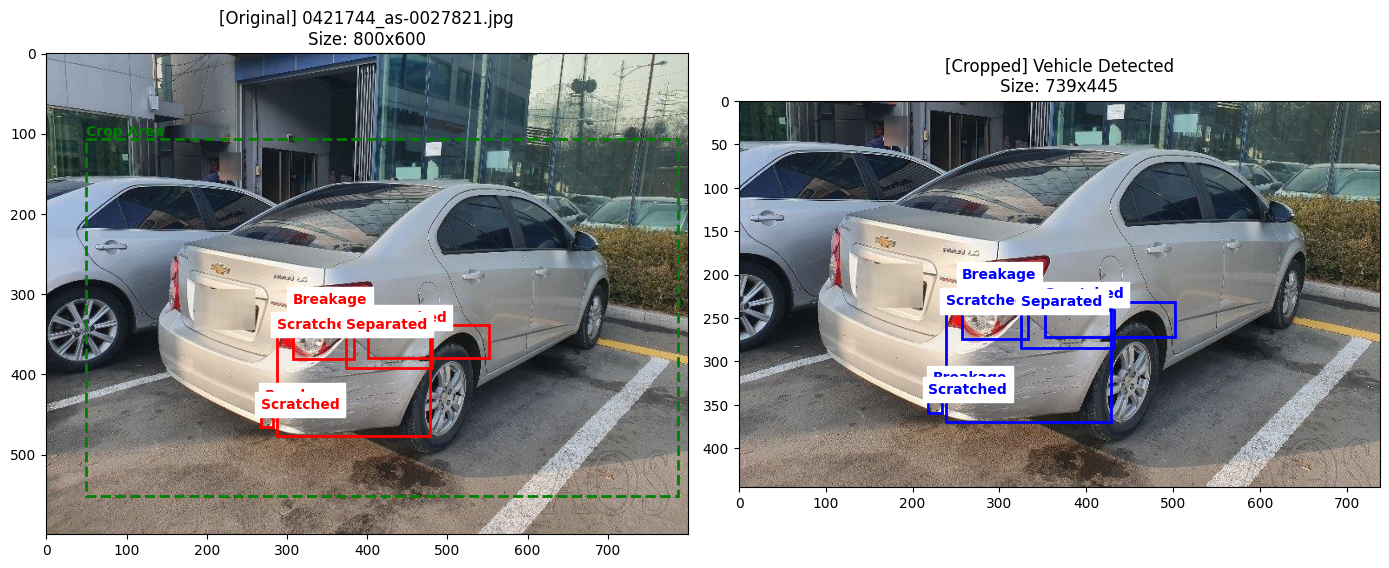

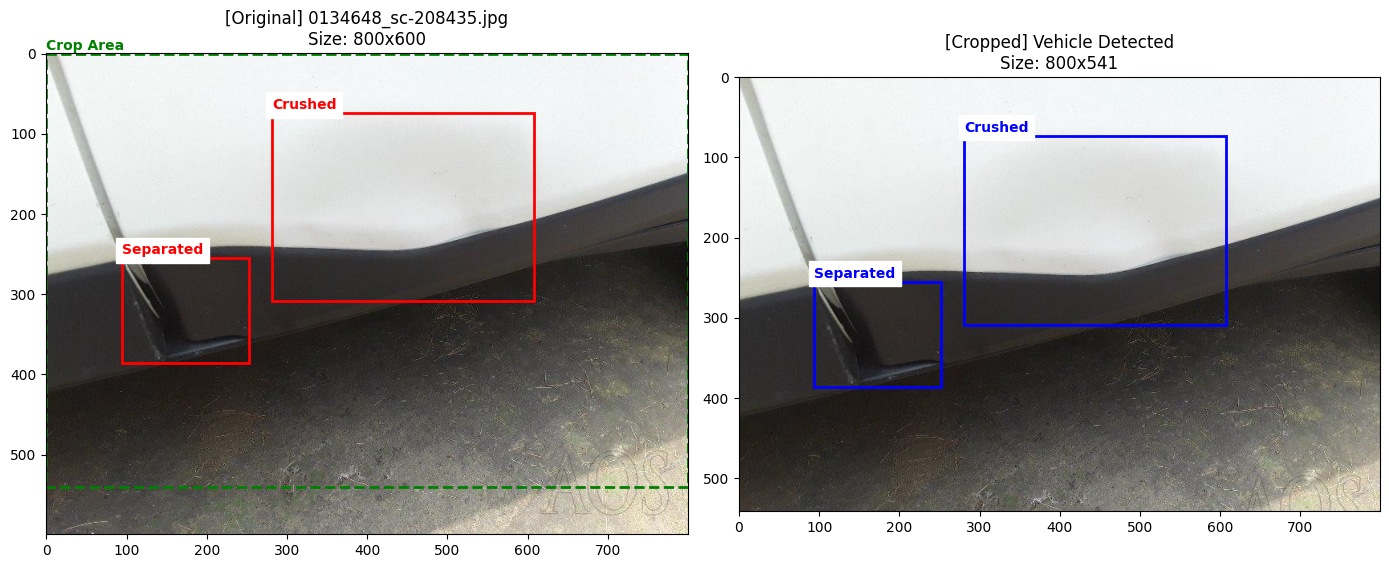

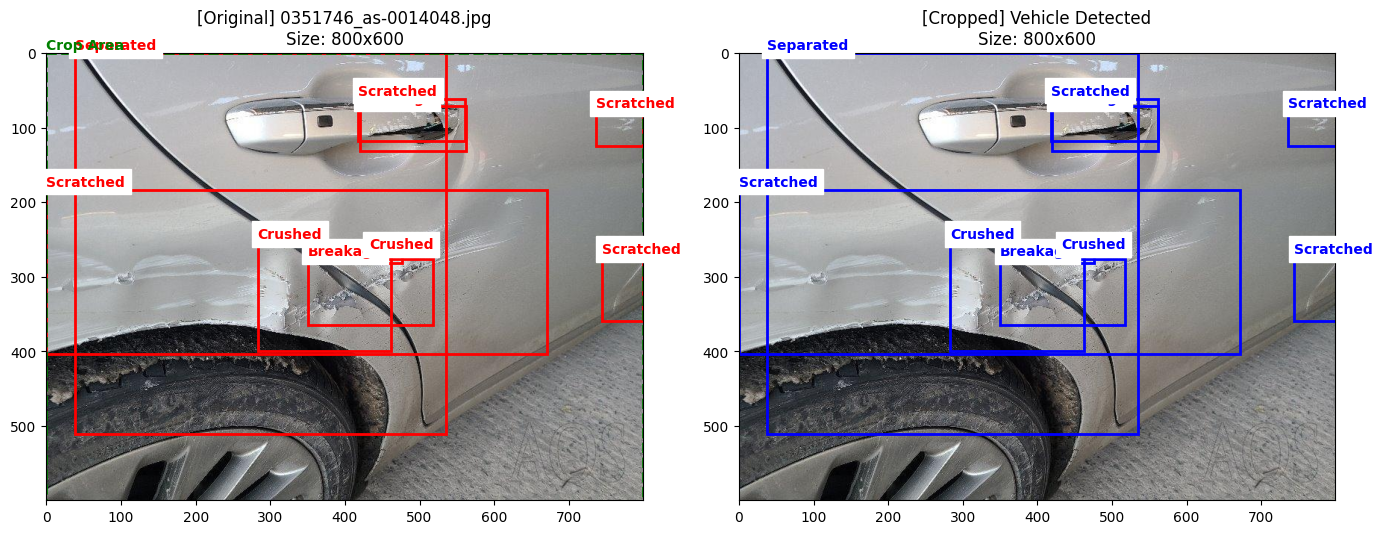

In [ ]:
# 실행
visualize_crop_comparison(STAGE1_MODEL_PATH, num_samples=3)

# 모델 학습

In [ ]:
# Week 3 과제 경로 설정
PROJECT_ROOT = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK3_CAR_DAMAGE_CATEGORIZATION"
SAVE_DIR = os.path.join(PROJECT_ROOT, "FINE_TUNING_MODEL")

def train_stage2():
    # [수정됨] 앞서 생성한 YAML 파일명과 일치시킴
    yaml_path = os.path.join(DATASET_ROOT, "data_multi_drive.yaml")

    model = YOLO('yolov8x.pt')

    print(f"🔥 Stage 2 Multi-Class 학습 시작...")
    print(f"   - Classes: {TARGET_CLASS_NAMES}")
    print(f"   - YAML Path: {yaml_path}")

    model.train(
        data=yaml_path,
        epochs=100,
        imgsz=640,
        batch=16,           # L4 GPU 최적화
        patience=25,
        optimizer='AdamW',
        lr0=1e-4,
        cos_lr=True,
        single_cls=False,   # ★ 핵심: 멀티 클래스 모드
        close_mosaic=10,
        project=SAVE_DIR,
        name='yolov8x_multi_class_final',
        exist_ok=True,
        verbose=True
    )

    best_pt = os.path.join(SAVE_DIR, 'yolov8x_multi_class_final', 'weights', 'best.pt')
    print(f"🏆 학습 완료! 모델 저장됨: {best_pt}")
    return best_pt

best_model_path = train_stage2()

🔥 Stage 2 Multi-Class 학습 시작...
   - Classes: ['Scratched', 'Separated', 'Breakage', 'Crushed']
   - YAML Path: /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI/data_multi_drive.yaml
Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI/data_multi_drive.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False,

In [2]:
import os

# 데이터셋 루트 경로 (구글 드라이브)
DATASET_ROOT = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI"

def check_dataset_status():
    if not os.path.exists(DATASET_ROOT):
        print(f"❌ 경로가 존재하지 않습니다: {DATASET_ROOT}")
        return

    print(f"📊 데이터셋 현황 분석 보고서")
    print(f"📂 타겟 경로: {DATASET_ROOT}")
    print("=" * 60)
    print(f"{'Split':<10} | {'Images':<10} | {'Labels':<10} | {'Status':<10}")
    print("-" * 60)

    total_imgs = 0
    total_lbls = 0

    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(DATASET_ROOT, 'images', split)
        lbl_dir = os.path.join(DATASET_ROOT, 'labels', split)

        # 파일 개수 세기
        n_imgs = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]) if os.path.exists(img_dir) else 0
        n_lbls = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')]) if os.path.exists(lbl_dir) else 0

        status = "✅ Perfect" if n_imgs == n_lbls and n_imgs > 0 else "⚠️ Check"
        if n_imgs == 0: status = "❌ Empty"

        print(f"{split:<10} | {n_imgs:<10} | {n_lbls:<10} | {status}")

        total_imgs += n_imgs
        total_lbls += n_lbls

    print("-" * 60)
    print(f"📌 [종합 요약]")
    print(f"   - 총 이미지 수 : {total_imgs} 장")
    print(f"   - 총 라벨 파일 : {total_lbls} 개")

    # YAML 파일 확인
    yaml_path = os.path.join(DATASET_ROOT, "data_multi_drive.yaml")
    if os.path.exists(yaml_path):
        print(f"   📄 YAML 파일 : ✅ 발견됨 ({os.path.basename(yaml_path)})")
    else:
        print(f"   📄 YAML 파일 : ❌ 없음 (생성 필요)")

# 실행
check_dataset_status()

📊 데이터셋 현황 분석 보고서
📂 타겟 경로: /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI
Split      | Images     | Labels     | Status    
------------------------------------------------------------
train      | 9153       | 9153       | ✅ Perfect
val        | 2616       | 2616       | ✅ Perfect
test       | 1308       | 1308       | ✅ Perfect
------------------------------------------------------------
📌 [종합 요약]
   - 총 이미지 수 : 13077 장
   - 총 라벨 파일 : 13077 개
   📄 YAML 파일 : ✅ 발견됨 (data_multi_drive.yaml)


## 성능 테스트(conf 0.25)

성능 평가 방법론: "계층적 파손 등급 평가 (Hierarchical Severity Evaluation)"
 - 기존의 단순 정확도(Accuracy)나 mAP(mean Average Precision)는 모든 파손을 동등하게 취급합니다. 하지만 보험/수리 현장에서는 "교환(Major)을 놓치는 것"이 "긁힘(Minor)을 놓치는 것"보다 훨씬 치명적입니다.
 - 따라서 우리는 아래와 같은 3단계 계층적 논리를 사용하여 모델을 평가합니다.

① 파손 등급 정의 (Severity Grading)이미지 내에 발견된 파손 종류에 따라 이미지 전체의 등급을 매깁니다. (높은 등급이 낮은 등급을 덮어씁니다)  
 🚨 Major (심각): Breakage, Separated, Crushed부품 교환이 필요한 파손입니다.이미지에 단 하나라도 존재하면 그 이미지는 Major 등급이 됩니다.  
 ⚠️ Minor (경미): Scratched도색/광택으로 복원 가능한 파손입니다.Major가 없고 Scratched만 있을 경우 Minor 등급이 됩니다.  
 🟩 Normal (정상): 파손 없음 (또는 Dent만 있음)사용자 요청에 따라 Dent는 평가에서 제외하며, Dent만 있는 경우 Normal로 취급합니다.  

② 핵심 평가지표 (Key Metrics)지표 이름의미비즈니스 목표
 - Major Recall실제 Major 사고 중 모델이 Major라고 맞춘 비율"위험 방어율" (최우선 목표, >90% 권장)
 - Minor Precision모델이 Minor라고 판단한 것 중 실제 Minor인 비율"업무 효율성" (오탐이 많으면 사람이 피곤함)
  - Critical Miss실제 Major인데, 모델이 Minor나 Normal로 오판한 비율"사고 발생율" (0%에 가까워야 함)

🚀 종합 성능 평가 시작 (Model: best.pt)
📂 분석 대상: 1308장
⏳ mAP 측정 중... (YOLO val)
Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 68,127,420 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.2±0.1 MB/s, size: 102.9 KB)
val: Scanning /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI/labels/test... 1308 images, 109 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1308/1308 1.7it/s 13:06
val: New cache created: /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 1.1s/it 1:29
                   all       1308       4024      0.378      0.309      0.261      0.124
Speed: 1.4ms preprocess, 61.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/r

  0%|          | 0/1308 [00:00<?, ?it/s]


📝 [YOLOv8x Comprehensive Benchmark Report]
Metric                    | Value               
--------------------------------------------------
GPU Spec                  | Tesla T4 (14.7 GB)
Total Test Images         | 1308
Overall Accuracy          | 74.24%
Fail Cases                | 337 images
mAP50                     | 0.2614
mAP50-95                  | 0.1236
--------------------------------------------------
Avg Inference Speed       | 70.90 ms/img
FPS                       | 14.10 frames/sec


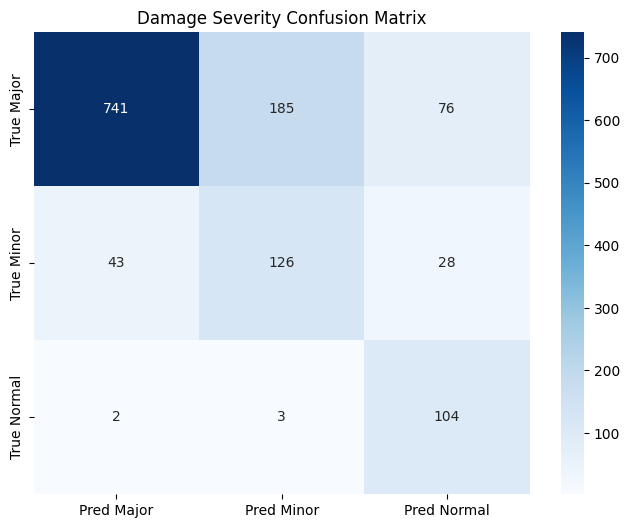

In [3]:
import os
import glob
import time
import torch
import subprocess
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from ultralytics import YOLO
from tqdm.auto import tqdm

# =========================================================
# ⚙️ [설정] 평가 환경 및 경로
# =========================================================
MODEL_PATH = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK3_CAR_DAMAGE_CATEGORIZATION/FINE_TUNING_MODEL/yolov8x_multi_class_final/weights/best.pt"
DATASET_ROOT = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI"

TEST_IMG_DIR = os.path.join(DATASET_ROOT, 'images', 'test')
TEST_LBL_DIR = os.path.join(DATASET_ROOT, 'labels', 'test')

# 클래스 및 등급 정의
CLASS_ID_TO_NAME = {0: 'Scratched', 1: 'Separated', 2: 'Breakage', 3: 'Crushed'}
GRADE_MAP = {'Breakage': 'Major', 'Separated': 'Major', 'Crushed': 'Major', 'Scratched': 'Minor'}
PRIORITY = {'Major': 3, 'Minor': 2, 'Normal': 1}

# =========================================================
# 🛠️ [함수] 유틸리티 (등급 결정 & GPU 정보)
# =========================================================
def get_image_grade(class_ids_list):
    if not class_ids_list: return 'Normal'
    current_max_score = 0; current_grade = 'Normal'
    for cls_id in class_ids_list:
        cls_name = CLASS_ID_TO_NAME.get(int(cls_id), 'Unknown')
        grade = GRADE_MAP.get(cls_name, 'Normal')
        score = PRIORITY.get(grade, 0)
        if score > current_max_score:
            current_max_score = score
            current_grade = grade
    return current_grade

def get_gpu_info():
    try:
        gpu_name = torch.cuda.get_device_name(0)
        mem_info = torch.cuda.mem_get_info(0)
        total_mem = mem_info[1] / 1024**3
        return f"{gpu_name} ({total_mem:.1f} GB)"
    except:
        return "CPU or Unknown"

# =========================================================
# 🚀 [실행] 종합 성능 평가 프로세스
# =========================================================
def evaluate_comprehensive():
    print(f"🚀 종합 성능 평가 시작 (Model: {os.path.basename(MODEL_PATH)})")

    if not os.path.exists(MODEL_PATH):
        print(f"❌ 모델 파일 없음: {MODEL_PATH}")
        return

    model = YOLO(MODEL_PATH)

    # 1. 파일 리스트업 (확장자 대소문자 무시)
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    test_files = sorted([
        os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)
        if os.path.splitext(f)[1].lower() in valid_exts
    ])

    total_count = len(test_files)
    print(f"📂 분석 대상: {total_count}장")

    # 2. mAP 측정 (YOLO val 모드 사용)
    # data.yaml 경로가 필요합니다. 데이터셋 루트에 있다고 가정합니다.
    yaml_path = os.path.join(DATASET_ROOT, "data_multi_drive.yaml")
    if not os.path.exists(yaml_path):
        # 만약 yaml 파일명이 다르면 여기서 수정해주세요
        yaml_path = glob.glob(os.path.join(DATASET_ROOT, "*.yaml"))[0]

    print("⏳ mAP 측정 중... (YOLO val)")
    val_results = model.val(data=yaml_path, split='test', verbose=False, conf=0.001)
    map50 = val_results.box.map50
    map50_95 = val_results.box.map

    # 3. 추론 및 등급 평가
    y_true, y_pred = [], []
    inference_times = []

    print("⏳ 이미지별 추론 및 등급 평가 중...")
    for img_path in tqdm(test_files):
        # GT 로드
        basename = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(TEST_LBL_DIR, basename + ".txt")
        gt_ids = []
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                gt_ids = [int(line.split()[0]) for line in f if line.strip()]
        y_true.append(get_image_grade(gt_ids))

        # 추론 시간 측정
        start_time = time.time()
        results = model.predict(img_path, conf=0.25, verbose=False)[0]
        end_time = time.time()
        inference_times.append((end_time - start_time) * 1000) # ms 단위

        # Pred 로드
        pred_ids = []
        if len(results.boxes) > 0:
            pred_ids = results.boxes.cls.cpu().numpy().astype(int).tolist()
        y_pred.append(get_image_grade(pred_ids))

    # 4. 지표 계산
    acc = accuracy_score(y_true, y_pred)
    fail_count = sum(1 for t, p in zip(y_true, y_pred) if t != p)
    avg_inf_speed = sum(inference_times) / len(inference_times)
    fps = 1000 / avg_inf_speed
    gpu_info = get_gpu_info()

    # 5. 리포트 출력
    print("\n" + "="*60)
    print(f"📝 [YOLOv8x Comprehensive Benchmark Report]")
    print("="*60)

    print(f"{'Metric':<25} | {'Value':<20}")
    print("-" * 50)
    print(f"{'GPU Spec':<25} | {gpu_info}")
    print(f"{'Total Test Images':<25} | {total_count}")
    print(f"{'Overall Accuracy':<25} | {acc:.2%}")
    print(f"{'Fail Cases':<25} | {fail_count} images")
    print(f"{'mAP50':<25} | {map50:.4f}")
    print(f"{'mAP50-95':<25} | {map50_95:.4f}")
    print("-" * 50)
    print(f"{'Avg Inference Speed':<25} | {avg_inf_speed:.2f} ms/img")
    print(f"{'FPS':<25} | {fps:.2f} frames/sec")
    print("="*60)

    # 6. Confusion Matrix 시각화
    labels = ['Major', 'Minor', 'Normal']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Major', 'Pred Minor', 'Pred Normal'],
                yticklabels=['True Major', 'True Minor', 'True Normal'])
    plt.title('Damage Severity Confusion Matrix')
    plt.show()

# 실행
evaluate_comprehensive()

## 성능 테스트 (0.25 -> 0.1)

🚀 종합 성능 평가 시작 (Model: best.pt)
📂 분석 대상: 1308장
⏳ mAP 측정 중... (YOLO val)
Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 68,127,420 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 2.5±2.4 ms, read: 14.0±3.4 MB/s, size: 107.9 KB)
val: Scanning /content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI/labels/test.cache... 1308 images, 109 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1308/1308 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 1.2s/it 1:36
                   all       1308       4024      0.378      0.309      0.261      0.124
Speed: 1.5ms preprocess, 61.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val2
⏳ 이미지별 추론 및 등급 평가 중...


  0%|          | 0/1308 [00:00<?, ?it/s]


📝 [YOLOv8x Comprehensive Benchmark Report]
Metric                    | Value               
--------------------------------------------------
GPU Spec                  | Tesla T4 (14.7 GB)
Total Test Images         | 1308
Overall Accuracy          | 83.56%
Fail Cases                | 215 images
mAP50                     | 0.2614
mAP50-95                  | 0.1236
--------------------------------------------------
Avg Inference Speed       | 71.08 ms/img
FPS                       | 14.07 frames/sec


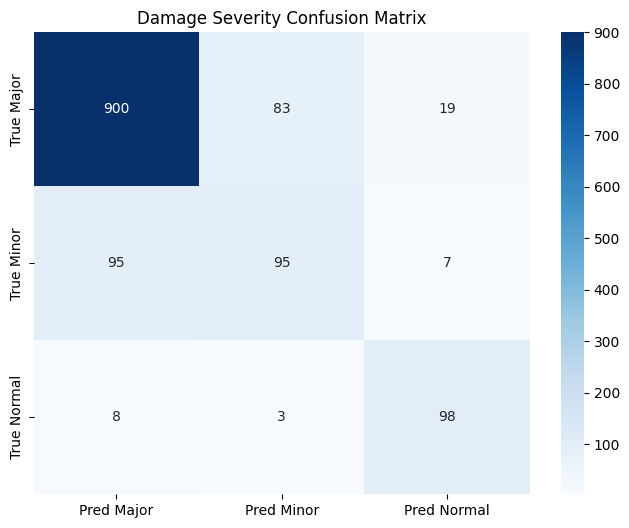

In [4]:
import os
import glob
import time
import torch
import subprocess
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from ultralytics import YOLO
from tqdm.auto import tqdm

# =========================================================
# ⚙️ [설정] 평가 환경 및 경로
# =========================================================
MODEL_PATH = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK3_CAR_DAMAGE_CATEGORIZATION/FINE_TUNING_MODEL/yolov8x_multi_class_final/weights/best.pt"
DATASET_ROOT = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI"

TEST_IMG_DIR = os.path.join(DATASET_ROOT, 'images', 'test')
TEST_LBL_DIR = os.path.join(DATASET_ROOT, 'labels', 'test')

# 클래스 및 등급 정의
CLASS_ID_TO_NAME = {0: 'Scratched', 1: 'Separated', 2: 'Breakage', 3: 'Crushed'}
GRADE_MAP = {'Breakage': 'Major', 'Separated': 'Major', 'Crushed': 'Major', 'Scratched': 'Minor'}
PRIORITY = {'Major': 3, 'Minor': 2, 'Normal': 1}

# =========================================================
# 🛠️ [함수] 유틸리티 (등급 결정 & GPU 정보)
# =========================================================
def get_image_grade(class_ids_list):
    if not class_ids_list: return 'Normal'
    current_max_score = 0; current_grade = 'Normal'
    for cls_id in class_ids_list:
        cls_name = CLASS_ID_TO_NAME.get(int(cls_id), 'Unknown')
        grade = GRADE_MAP.get(cls_name, 'Normal')
        score = PRIORITY.get(grade, 0)
        if score > current_max_score:
            current_max_score = score
            current_grade = grade
    return current_grade

def get_gpu_info():
    try:
        gpu_name = torch.cuda.get_device_name(0)
        mem_info = torch.cuda.mem_get_info(0)
        total_mem = mem_info[1] / 1024**3
        return f"{gpu_name} ({total_mem:.1f} GB)"
    except:
        return "CPU or Unknown"

# =========================================================
# 🚀 [실행] 종합 성능 평가 프로세스
# =========================================================
def evaluate_comprehensive():
    print(f"🚀 종합 성능 평가 시작 (Model: {os.path.basename(MODEL_PATH)})")

    if not os.path.exists(MODEL_PATH):
        print(f"❌ 모델 파일 없음: {MODEL_PATH}")
        return

    model = YOLO(MODEL_PATH)

    # 1. 파일 리스트업 (확장자 대소문자 무시)
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    test_files = sorted([
        os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)
        if os.path.splitext(f)[1].lower() in valid_exts
    ])

    total_count = len(test_files)
    print(f"📂 분석 대상: {total_count}장")

    # 2. mAP 측정 (YOLO val 모드 사용)
    # data.yaml 경로가 필요합니다. 데이터셋 루트에 있다고 가정합니다.
    yaml_path = os.path.join(DATASET_ROOT, "data_multi_drive.yaml")
    if not os.path.exists(yaml_path):
        # 만약 yaml 파일명이 다르면 여기서 수정해주세요
        yaml_path = glob.glob(os.path.join(DATASET_ROOT, "*.yaml"))[0]

    print("⏳ mAP 측정 중... (YOLO val)")
    val_results = model.val(data=yaml_path, split='test', verbose=False, conf=0.001)
    map50 = val_results.box.map50
    map50_95 = val_results.box.map

    # 3. 추론 및 등급 평가
    y_true, y_pred = [], []
    inference_times = []

    print("⏳ 이미지별 추론 및 등급 평가 중...")
    for img_path in tqdm(test_files):
        # GT 로드
        basename = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(TEST_LBL_DIR, basename + ".txt")
        gt_ids = []
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                gt_ids = [int(line.split()[0]) for line in f if line.strip()]
        y_true.append(get_image_grade(gt_ids))

        # 추론 시간 측정
        start_time = time.time()
        results = model.predict(img_path, conf=0.1, verbose=False)[0]
        end_time = time.time()
        inference_times.append((end_time - start_time) * 1000) # ms 단위

        # Pred 로드
        pred_ids = []
        if len(results.boxes) > 0:
            pred_ids = results.boxes.cls.cpu().numpy().astype(int).tolist()
        y_pred.append(get_image_grade(pred_ids))

    # 4. 지표 계산
    acc = accuracy_score(y_true, y_pred)
    fail_count = sum(1 for t, p in zip(y_true, y_pred) if t != p)
    avg_inf_speed = sum(inference_times) / len(inference_times)
    fps = 1000 / avg_inf_speed
    gpu_info = get_gpu_info()

    # 5. 리포트 출력
    print("\n" + "="*60)
    print(f"📝 [YOLOv8x Comprehensive Benchmark Report]")
    print("="*60)

    print(f"{'Metric':<25} | {'Value':<20}")
    print("-" * 50)
    print(f"{'GPU Spec':<25} | {gpu_info}")
    print(f"{'Total Test Images':<25} | {total_count}")
    print(f"{'Overall Accuracy':<25} | {acc:.2%}")
    print(f"{'Fail Cases':<25} | {fail_count} images")
    print(f"{'mAP50':<25} | {map50:.4f}")
    print(f"{'mAP50-95':<25} | {map50_95:.4f}")
    print("-" * 50)
    print(f"{'Avg Inference Speed':<25} | {avg_inf_speed:.2f} ms/img")
    print(f"{'FPS':<25} | {fps:.2f} frames/sec")
    print("="*60)

    # 6. Confusion Matrix 시각화
    labels = ['Major', 'Minor', 'Normal']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Major', 'Pred Minor', 'Pred Normal'],
                yticklabels=['True Major', 'True Minor', 'True Normal'])
    plt.title('Damage Severity Confusion Matrix')
    plt.show()

# 실행
evaluate_comprehensive()

In [22]:
95/1003

0.09471585244267199

## 시각화

In [5]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =========================================================
# 🔍 [만능 함수] 조건별 그리드 시각화 (5행 4열)
# =========================================================
def find_file_path(root_dir, filename):
    """
    root_dir: 검색을 시작할 최상위 폴더 (예: AI_HUB_IMG_ROOT)
    filename: 찾고 싶은 파일 이름 (예: 'image_01.jpg')
    """

    # os.walk: root_dir 아래에 있는 모~든 하위 폴더를 샅샅이 뒤집니다.
    for root, dirs, files in os.walk(root_dir):

        # 만약 현재 뒤지고 있는 폴더(root)에 찾는 파일(filename)이 있다면?
        if filename in files:
            # "찾았다!" -> 경로를 합쳐서(join) 전체 주소를 반환하고 함수를 즉시 종료합니다.
            return os.path.join(root, filename)

    # 끝까지 다 뒤져도 없으면 None(없음)을 반환합니다.
    return None

def visualize_custom_grid(model, y_true, y_pred, test_files, target_actual, target_pred, start_index=0, batch_size=20):
    """
    params:
      - target_actual: 보고 싶은 실제 등급 (예: 'Major' 또는 ['Minor', 'Normal'])
      - target_pred:   보고 싶은 예측 등급 (예: 'Minor' 또는 ['Major'])
    """

    # 1. 입력값을 리스트로 변환 (문자열 하나만 넣어도 리스트로 처리되게 함)
    if isinstance(target_actual, str): target_actual = [target_actual]
    if isinstance(target_pred, str):   target_pred = [target_pred]

    # 2. 조건에 맞는 인덱스 필터링
    target_indices = []
    for i, (t, p) in enumerate(zip(y_true, y_pred)):
        # 실제값이 target_actual에 포함되고, 예측값이 target_pred에 포함되면 추가
        if t in target_actual and p in target_pred:
            target_indices.append(i)

    # 데이터가 없는 경우 처리
    if not target_indices:
        print(f"⚠️ 조건에 맞는 데이터가 없습니다. (Actual: {target_actual} vs Pred: {target_pred})")
        return

    # 3. 페이징 처리
    if start_index >= len(target_indices):
        print("✅ 더 이상 확인할 이미지가 없습니다.")
        return

    end_index = min(start_index + batch_size, len(target_indices))
    current_batch_indices = target_indices[start_index : end_index]

    print(f"🚀 분석 시작: Actual {target_actual} vs Pred {target_pred}")
    print(f"   📊 조회 구간: {start_index} ~ {end_index-1} (총 {len(target_indices)}건 중)")

    # 4. 그리드 설정 (5행 4열)
    ROWS = 5
    COLS = 4
    plt.figure(figsize=(24, 20)) # 큰 화면

    for idx, list_idx in enumerate(current_batch_indices):
        crop_path = test_files[list_idx]
        fname = os.path.basename(crop_path)
        txt_fname = os.path.splitext(fname)[0] + ".txt"

        # 원본 찾기
        original_img_path = find_file_path(AI_HUB_IMG_ROOT, fname)
        original_lbl_path = find_file_path(AI_HUB_LBL_ROOT, txt_fname)

        if not original_img_path: continue

        img_org = cv2.imread(original_img_path)
        if img_org is None: continue
        img_org = cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)
        h_org, w_org = img_org.shape[:2]

        # 스타일 설정
        BOX_THICKNESS = 2
        FONT_SCALE = 0.5
        FONT_THICKNESS = 1

        # [A] GT 그리기 (초록색)
        gt_texts = []
        if original_lbl_path:
            with open(original_lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls_id = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])

                    x1 = int((cx - w/2) * w_org)
                    y1 = int((cy - h/2) * h_org)
                    x2 = int((cx + w/2) * w_org)
                    y2 = int((cy + h/2) * h_org)

                    cls_name = CLASS_ID_TO_NAME.get(cls_id, 'Unknown')

                    cv2.rectangle(img_org, (x1, y1), (x2, y2), (0, 255, 0), BOX_THICKNESS)
                    gt_texts.append(cls_name)

                    label = f"GT:{cls_name}"
                    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, FONT_THICKNESS)
                    cv2.rectangle(img_org, (x1, y1-th-5), (x1+tw, y1), (0, 255, 0), -1)
                    cv2.putText(img_org, label, (x1, y1-5),
                               cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 0, 0), FONT_THICKNESS)

        # [B] Pred 그리기 (빨간색)
        cx1, cy1, cx2, cy2, detected = get_vehicle_crop_box(img_org, model_stage1, margin=0.15)
        crop_img = img_org[cy1:cy2, cx1:cx2]
        pred_texts = []

        if crop_img.size > 0:
            results = model.predict(crop_img, conf=0.1, verbose=False)[0]
            for box in results.boxes:
                p_cls = int(box.cls)
                p_conf = float(box.conf)
                px1, py1, px2, py2 = map(int, box.xyxy[0])

                ox1, oy1 = px1 + cx1, py1 + cy1
                ox2, oy2 = px2 + cx1, py2 + cy1

                p_name = CLASS_ID_TO_NAME.get(p_cls, 'Unknown')
                pred_texts.append(p_name)

                cv2.rectangle(img_org, (ox1, oy1), (ox2, oy2), (255, 0, 0), BOX_THICKNESS)

                label = f"Pred:{p_name} {p_conf:.2f}"
                cv2.putText(img_org, label, (ox1, oy2+15),
                           cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (255, 0, 0), FONT_THICKNESS+1)

        # [C] 출력
        gt_str = ", ".join(set(gt_texts)) if gt_texts else "Normal"
        pred_str = ", ".join(set(pred_texts)) if pred_texts else "Normal"

        # 제목 색상 결정 (정답이면 초록, 오답이면 빨강)
        title_color = 'green' if y_true[list_idx] == y_pred[list_idx] else 'red'

        plt.subplot(ROWS, COLS, idx + 1)
        plt.imshow(img_org)
        plt.title(f"[{start_index + idx}] Actual:{y_true[list_idx]} / Pred:{y_pred[list_idx]}\nGT:{gt_str} / P:{pred_str}",
                  fontsize=10, fontweight='bold', color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
MODEL_PATH = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK3_CAR_DAMAGE_CATEGORIZATION/FINE_TUNING_MODEL/yolov8x_multi_class_final/weights/best.pt"
model = YOLO(MODEL_PATH)  # 모델이 로드되어 있어야 함
AI_HUB_IMG_ROOT = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/AI_HUB_DAMAGE_DATASET/images" # 속도 개선을 위해 content에 직접 업로드
AI_HUB_LBL_ROOT = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/AI_HUB_DAMAGE_DATASET/labels"
model_stage1 = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK1_CAR_DETECTION/FINE_TUNING_MODEL/yolov8x_fine_tuning_5th/weights/best.pt"


import os
import glob
from ultralytics import YOLO
from tqdm.auto import tqdm

# 1. 모델 및 경로 설정
MODEL_PATH = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/SUBJECT/WEEK3_CAR_DAMAGE_CATEGORIZATION/FINE_TUNING_MODEL/yolov8x_multi_class_final/weights/best.pt"
DATASET_ROOT = "/content/drive/MyDrive/03. HDMF/(pre_study)2026_HDMF_AUTO_SPOKE/DATA/CAR_DAMAGE_DATASET_STAGE2_MULTI"
TEST_IMG_DIR = os.path.join(DATASET_ROOT, 'images', 'test')
TEST_LBL_DIR = os.path.join(DATASET_ROOT, 'labels', 'test')

# 2. 매핑 정보
CLASS_ID_TO_NAME = {0: 'Scratched', 1: 'Separated', 2: 'Breakage', 3: 'Crushed'}
GRADE_MAP = {'Breakage': 'Major', 'Separated': 'Major', 'Crushed': 'Major', 'Scratched': 'Minor'}
PRIORITY = {'Major': 3, 'Minor': 2, 'Normal': 1}

# 3. 헬퍼 함수
def get_image_grade(class_ids_list):
    if not class_ids_list: return 'Normal'
    current_max_score = 0; current_grade = 'Normal'
    for cls_id in class_ids_list:
        cls_name = CLASS_ID_TO_NAME.get(int(cls_id), 'Unknown')
        grade = GRADE_MAP.get(cls_name, 'Normal')
        score = PRIORITY.get(grade, 0)
        if score > current_max_score:
            current_max_score = score
            current_grade = grade
    return current_grade

def find_file_path(root_dir, filename):
    for root, dirs, files in os.walk(root_dir):
        if filename in files: return os.path.join(root, filename)
    return None

def get_vehicle_crop_box(image, model, margin=0.15):
    # (시각화용 Crop 함수 - 이전에 정의된 것을 사용하거나 간단히 전체 반환 처리)
    # 여기서는 시각화 코드에 필요한 함수가 정의되어 있어야 하므로,
    # 혹시 모를 에러 방지를 위해 간단한 버전을 포함합니다.
    h, w = image.shape[:2]
    return 0, 0, w, h, False # Fallback

# 4. [핵심] 평가 수행 및 변수 반환
def run_evaluation_for_viz():
    print(f"🚀 시각화 데이터를 생성합니다 (Model: {os.path.basename(MODEL_PATH)})")
    model = YOLO(MODEL_PATH)

    # 파일 리스트
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    test_files = sorted([
        os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)
        if os.path.splitext(f)[1].lower() in valid_exts
    ])

    y_true = []
    y_pred = []

    print("⏳ 데이터 스캔 중...")
    for img_path in tqdm(test_files):
        # GT
        basename = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(TEST_LBL_DIR, basename + ".txt")
        gt_ids = []
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                gt_ids = [int(line.split()[0]) for line in f if line.strip()]
        y_true.append(get_image_grade(gt_ids))

        # Pred
        results = model.predict(img_path, conf=0.1, verbose=False)[0] # conf=0.1 중요!
        pred_ids = []
        if len(results.boxes) > 0:
            pred_ids = results.boxes.cls.cpu().numpy().astype(int).tolist()
        y_pred.append(get_image_grade(pred_ids))

    return model, y_true, y_pred, test_files

# 5. 실행하여 변수에 저장 (이 줄이 없어서 에러가 났던 것입니다!)
model, y_true, y_pred, test_files = run_evaluation_for_viz()
print("✅ 준비 완료! 이제 시각화 코드를 실행하세요.")


🚀 시각화 데이터를 생성합니다 (Model: best.pt)
⏳ 데이터 스캔 중...


  0%|          | 0/1308 [00:00<?, ?it/s]

✅ 준비 완료! 이제 시각화 코드를 실행하세요.


In [13]:
visualize_custom_grid(model, y_true, y_pred, test_files,
                      target_actual='Major',
                      target_pred=['Minor', 'Normal'],
                      start_index=0)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
visualize_custom_grid(model, y_true, y_pred, test_files,
                      target_actual='Minor',
                      target_pred='Major',
                      start_index=0)

Output hidden; open in https://colab.research.google.com to view.

🚀 분석 시작: Actual ['Normal'] vs Pred ['Major', 'Minor']
   📊 조회 구간: 0 ~ 10 (총 11건 중)


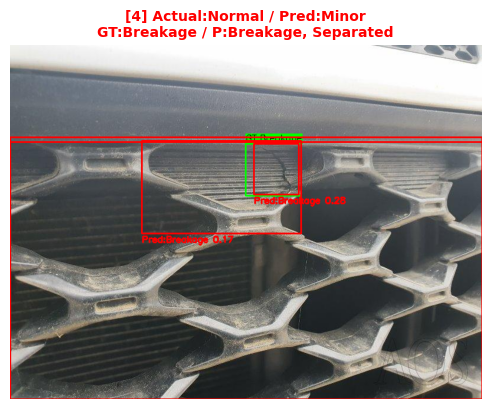

In [16]:
visualize_custom_grid(model, y_true, y_pred, test_files,
                      target_actual='Normal',
                      target_pred=['Major', 'Minor'],
                      start_index=0)

In [17]:
visualize_custom_grid(model, y_true, y_pred, test_files,
                      target_actual='Normal',
                      target_pred=['Major'],
                      start_index=0)

🚀 분석 시작: Actual ['Normal'] vs Pred ['Major']
   📊 조회 구간: 0 ~ 7 (총 8건 중)


<Figure size 2400x2000 with 0 Axes>